# Imports & setup

In [42]:
import os # File handling
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

In [43]:
current_file_dir = os.getcwd() # Get current directory
project_root = os.path.dirname(current_file_dir) # Get project root

# Ingestion

In [44]:
df = pd.read_csv(f"{project_root}/data_raw/StudentsPerformance_raw.csv")


# Preprocessing

In [45]:
df.shape

(1000, 8)

In [46]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [47]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [48]:
for col in df.columns:
    print(df[col].name)
    print(df[col].unique())
    print()

gender
<StringArray>
['female', 'male']
Length: 2, dtype: str

race/ethnicity
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

parental level of education
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

lunch
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

test preparation course
<StringArray>
['none', 'completed']
Length: 2, dtype: str

math score
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]

reading score
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  

In [49]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

No missing values could be found for this data.

In [50]:
df.to_csv(f"{project_root}/data_clean/StudentsPerformance_clean.csv") # Save CSV file

# Visualizations

Figure config settigns

In [51]:
# Set params for fig
width_px = 800
height_px = 600
dpi = 300
fontsize = 4
title_fontsize = 6

# Calc size for matplotlib
width_in = width_px / dpi
height_in = height_px / dpi

## V1

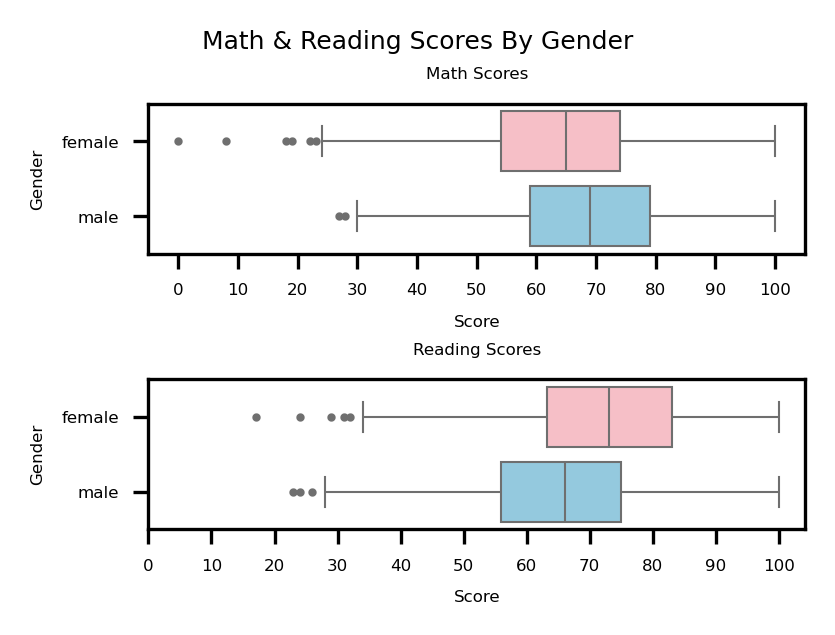

In [52]:
# Create figure
figure, axes = plt.subplots(nrows=2, ncols=1, figsize=(width_in, height_in), dpi=dpi)
figure.suptitle("Math & Reading Scores By Gender", fontsize=title_fontsize) # Set title

# Create boxplot for math scores
sns.boxplot(data=df,
            y="gender",
            x="math score",
            linewidth=0.5,
            fliersize=1,
            hue="gender",
            palette={
                "male": "skyblue",
                "female": "lightpink"
                },
            ax=axes[0]
            )
axes[0].set_xticks(range(0, 101, 10)) # Set ticks interval
axes[0].tick_params(labelsize=fontsize) # Set tick size
axes[0].set_title("Math Scores", fontsize=fontsize) # Set sub plot title
axes[0].set_xlabel("Score", fontsize=fontsize) # Set x axis label
axes[0].set_ylabel("Gender", fontsize=fontsize) # Set y axis label

# Create boxplot for reading scores
sns.boxplot(data=df,
            y="gender",
            x="reading score",
            linewidth=0.5,
            fliersize=1,
            hue="gender",
            palette={
                "male": "skyblue",
                "female": "lightpink"
                },
            ax=axes[1]
            )
axes[1].set_xticks(range(0, 101, 10)) # Set ticks interval
axes[1].tick_params(labelsize=fontsize) # Set tick size
axes[1].set_title("Reading Scores", fontsize=fontsize) # Set sub plot title
axes[1].set_xlabel("Score", fontsize=fontsize) # Set x axis label
axes[1].set_ylabel("Gender", fontsize=fontsize) # Set y axis label

plt.tight_layout(pad=0.3) # Set layout
plt.show() # Display figure

figure.savefig(f"{project_root}/reports/v1_math_reading_scores_by_gender.png", dpi=dpi) # Save figure

## V2

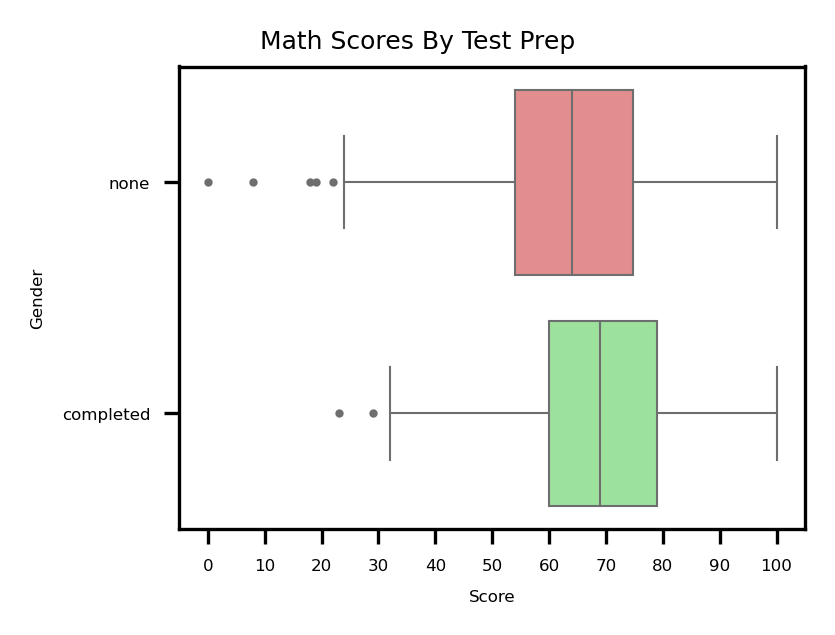

In [53]:
# Create figure
figure = plt.figure(figsize=(width_in, height_in), dpi=dpi)
figure.suptitle("Math Scores By Test Prep", fontsize=title_fontsize) # Set title

# Create boxplot for math scores
p = sns.boxplot(data=df,
            y="test preparation course",
            x="math score",
            linewidth=0.5,
            fliersize=1,
            hue="test preparation course",
            palette={
                "completed": "lightgreen",
                "none": "lightcoral"
                }
            )
p.set_xticks(range(0, 101, 10)) # Set ticks interval
p.tick_params(labelsize=fontsize) # Set tick size
p.set_xlabel("Score", fontsize=fontsize) # Set x axis label
p.set_ylabel("Gender", fontsize=fontsize) # Set y axis label

plt.tight_layout(pad=0.3) # Set layout
plt.show() # Display figure

figure.savefig(f"{project_root}/reports/v2_math_scores_by_test_prep.png", dpi=dpi) # Save figure

## V3

In [54]:
# Make df for each score by subject and lunch type
overall_avg = df.melt(
    id_vars="lunch",
    value_vars=["math score", "reading score", "writing score"],
    var_name="subject",
    value_name="score"
)
print(overall_avg)

             lunch        subject  score
0         standard     math score     72
1         standard     math score     69
2         standard     math score     90
3     free/reduced     math score     47
4         standard     math score     76
...            ...            ...    ...
2995      standard  writing score     95
2996  free/reduced  writing score     55
2997  free/reduced  writing score     65
2998      standard  writing score     77
2999  free/reduced  writing score     86

[3000 rows x 3 columns]


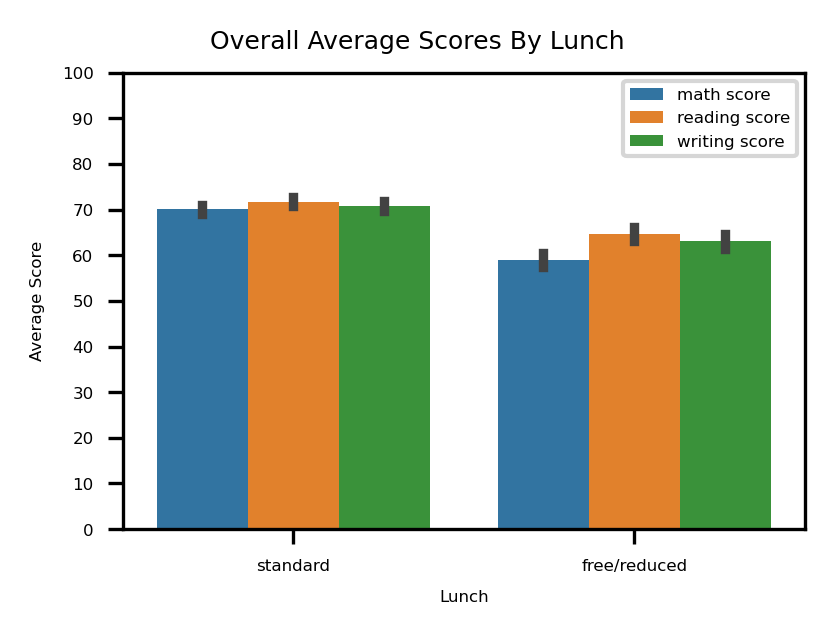

In [55]:
# Create figure
figure = plt.figure(figsize=(width_in, height_in), dpi=dpi)
figure.suptitle("Overall Average Scores By Lunch", fontsize=title_fontsize) # Set title

# Create boxplot for math scores
p = sns.barplot(
    data=overall_avg,
    x="lunch",
    y="score",
    hue="subject"
)
p.set_yticks(range(0, 101, 10)) # Set ticks interval
p.tick_params(labelsize=fontsize) # Set tick size
p.set_xlabel("Lunch", fontsize=fontsize) # Set x axis label
p.set_ylabel("Average Score", fontsize=fontsize) # Set y axis label
p.legend(fontsize=fontsize)

plt.tight_layout(pad=0.3) # Set layout
plt.show() # Display figure

figure.savefig(f"{project_root}/reports/v3_overall_average_score_by_lunch.png", dpi=dpi) # Save figure

# V4

In [56]:
# Get score correlations
score_corr = df[["math score", "reading score", "writing score"]].corr()
print(score_corr)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


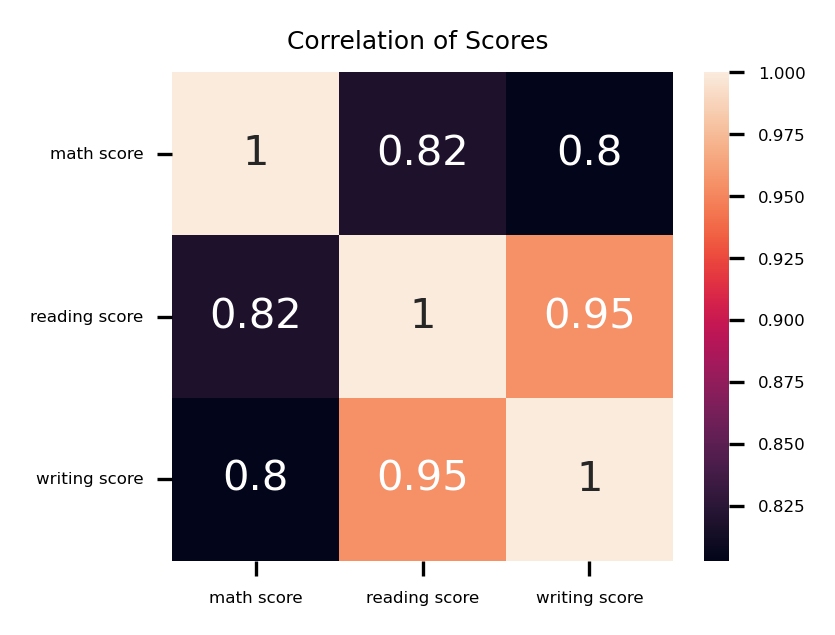

In [57]:
# Create figure
figure = plt.figure(figsize=(width_in, height_in), dpi=dpi)
figure.suptitle("Correlation of Scores", fontsize=title_fontsize) # Set title

# Create boxplot for math scores
p = sns.heatmap(
    data=score_corr,
    annot=True
)
p.tick_params(labelsize=fontsize) # Set tick size
p.figure.axes[-1].tick_params(labelsize=fontsize) # Set scale color bar font size

plt.xticks(rotation=0)

plt.tight_layout(pad=0.3) # Set layout
plt.show() # Display figure

figure.savefig(f"{project_root}/reports/v4_score_correlations.png", dpi=dpi) # Save figure

# V5

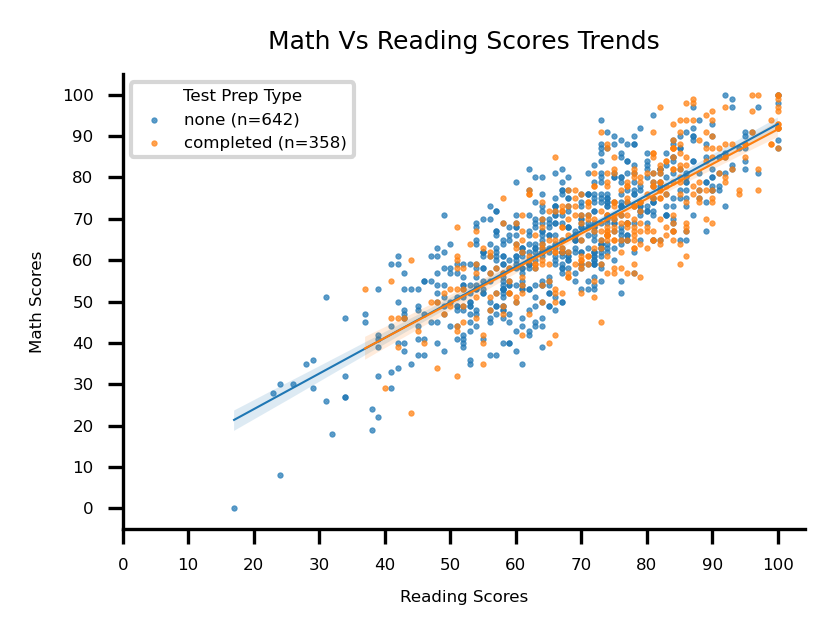

In [58]:
# Create regression scatter plot with lines
p = sns.lmplot(
    height=height_in,
    aspect=width_in / height_in,
    data=df,
    x="reading score",
    y="math score",
    hue="test preparation course",
    legend=False,
    scatter_kws={"s": 0.25},
    line_kws={"lw": 0.5}
)
p.ax.set_yticks(range(0, 101, 10)) # Set ticks interval
p.ax.set_xticks(range(0, 101, 10)) # Set ticks interval
p.tick_params(labelsize=fontsize) # Set tick size
p.ax.set_xlabel("Reading Scores", fontsize=fontsize) # Set x axis label
p.ax.set_ylabel("Math Scores", fontsize=fontsize) # Set y axis label

counts = df["test preparation course"].value_counts() # Get value counts n
handles, labels = p.ax.get_legend_handles_labels() # Get handles + labels for legend
# Create legend
p.ax.legend(
    title="Test Prep Type",
    title_fontsize=fontsize,
    labels=[f"{label} (n={counts[label]})" for label in labels],
    handles=handles,
    fontsize=fontsize
)
p.ax.set_title("Math Vs Reading Scores Trends", fontsize=title_fontsize) # Set figure title

p.figure.set_dpi(dpi) # Set figure dpi

p.figure.tight_layout(pad=0.3) # Set layout

p.figure.savefig(f"{project_root}/reports/v5_math_vs_reading_test_prep_trends.png", dpi=dpi) # Save figure